In [1]:
from langchain_groq import ChatGroq
from dotenv import load_dotenv    
load_dotenv()

from src.sdlc_system.state.state_file import  SDLCState , UserStoryList


from src.sdlc_system.graph.build_graph import GraphBuilder
from src.sdlc_system.graph.graph_executor import GraphExecutor

import os

In [ ]:
# llm = ChatGroq(
#     model_name="openai/gpt-oss-20b",
#     api_key=""
# )

# response = llm.invoke("Say hello in one line")

# print(response.content)

In [2]:
llm = ChatGroq(model = 'openai/gpt-oss-20b')

In [3]:
llm.invoke("India Capital")

AIMessage(content='The capital of India is **New\u202fDelhi**.', additional_kwargs={'reasoning_content': 'User says "India Capital". Likely they want the capital of India. The capital of India is New Delhi. Provide answer. Possibly mention that New Delhi is the capital.'}, response_metadata={'token_usage': {'completion_tokens': 56, 'prompt_tokens': 73, 'total_tokens': 129, 'completion_time': 0.05686986, 'completion_tokens_details': {'reasoning_tokens': 36}, 'prompt_time': 0.004925933, 'prompt_tokens_details': None, 'queue_time': 0.048506192, 'total_time': 0.061795793}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_c5a89987dc', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019dbda6-ab2e-70e2-bd05-6af451f2ec6f-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 56, 'total_tokens': 129, 'output_token_details': {'reasoning': 36}})

# Graph

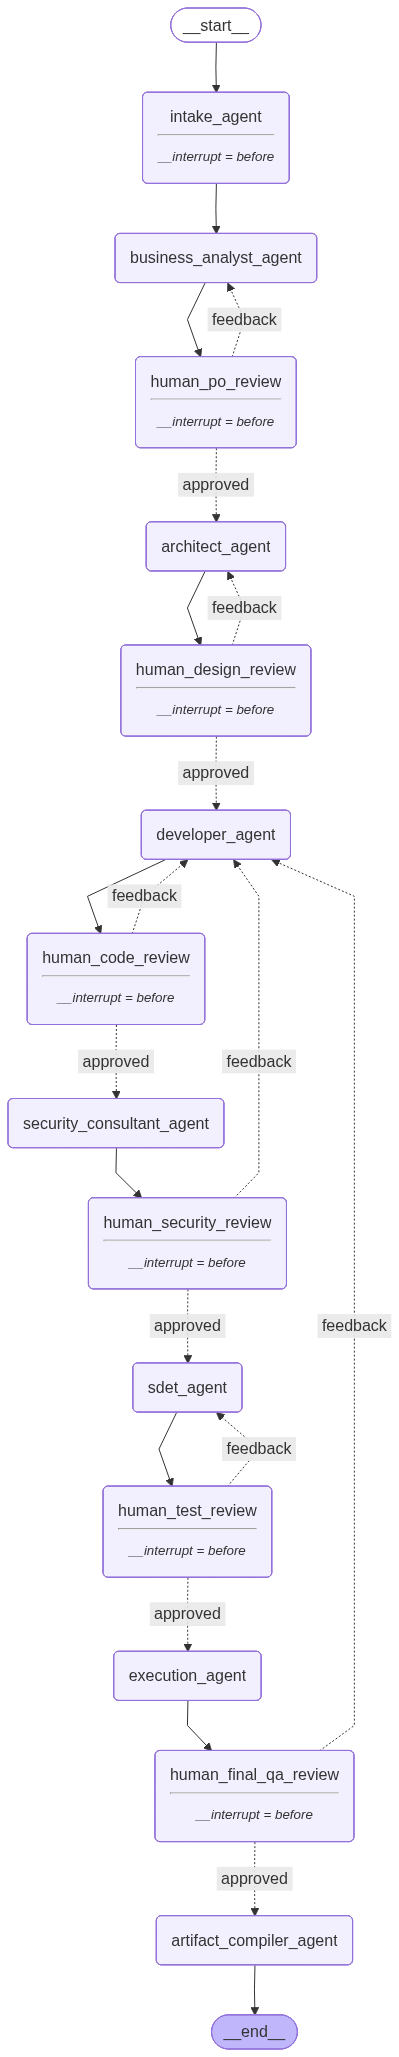

In [4]:
graph_builder = GraphBuilder(llm)
graph = graph_builder.setup_graph()

graph

In [ ]:
graph_executor = GraphExecutor(graph)

In [ ]:
# Step 1: Start with just the Project Name
project_name = "Food Delivery App"
start_response = graph_executor.start_workflow(project_name)

task_id = start_response["task_id"]
print(f"Workflow started with Task ID: {task_id}")

In [ ]:
# Step 2: Pass requirements later using the task_id
requirements = [
    "User can order food",
    "User can track order",
    "User can make payments"
]
final_response = graph_executor.generate_stories(task_id, requirements)

In [ ]:
final_response

In [ ]:
print(final_response['state']['user_stories'])

In [ ]:
final_response['state']['user_stories'].user_stories

In [ ]:
# Provide "approved" status to move the graph to END
approval_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="approved", 
    feedback="", 
    review_type="review_user_stories"
)

print("Workflow Status:", approval_response['state']['next_node'] if approval_response['state'].get('next_node') else "Finished")

In [ ]:
# Provide feedback to trigger a revision loop
feedback_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="feedback", 
    feedback="Add one more user story", 
    review_type="review_user_stories"
)

# Display the newly regenerated stories
feedback_response['state']['user_stories'].user_stories

In [ ]:
# See what the manual tracker says
feedback_response['state']

In [ ]:
approval_response = graph_executor.graph_review_flow(
    task_id=task_id, 
    status="approved", 
    feedback="", 
    review_type="review_user_stories"
)

print("Workflow Status:", approval_response['state']['next_node'] if approval_response['state'].get('next_node') else "Finished")

In [ ]:
approval_response